### libs

In [22]:
# !pip install pandas
#!pip install seaborn

In [23]:
import pandas as pd
import unicodedata
import numpy as np
import re
import joblib

### funções

In [24]:
def verificarGradePesos(x):
    dfGrade = pd.read_excel("./database/gold/gradePesos.xlsx")
    
    # Adicione estas duas linhas para forçar a tipagem para string
    dfGrade["modelo"] = dfGrade["modelo"].astype(str)
    dfGrade["pin"] = dfGrade["pin"].astype(str)
    
    mask = (
        (dfGrade["modelo"] == str(x["CD_MODELO"])) &
        (dfGrade["pin"] == str(x["CD_PIN"]))
    )
    return not dfGrade.loc[mask].empty

In [25]:
def verificarModelo(x):
    dfModelo = pd.read_excel("./database/gold/modeloAngariacao.xlsx")
    
    # Forçando tipagem para string
    dfModelo["modelo"] = dfModelo["modelo"].astype(str)
    dfModelo["segmento"] = dfModelo["segmento"].astype(str)
    
    mask = (
        (dfModelo["modelo"] == str(x["CD_MODELO"])) &
        (dfModelo["segmento"] == str(x["CD_SEGMENTO"]))
    )
    return not dfModelo.loc[mask].empty

In [26]:
def forceType(df, t):
    for column in df.columns:
        df[column] = df[column].astype(t)

    return df

In [27]:
def _preparar_features(df_diario, df_corpao):
    """
    Faz o Join e prepara APENAS as features matemáticas (sem np.select).
    """
    df_esq = df_diario.copy()
    
    # 1. Chave e Join
    df_esq['regexContrato'] = df_esq['NR_CONTRATO'].apply(lambda x: re.findall(r'66\d+', str(x))[0] if re.findall(r'66\d+', str(x)) else None)
    df_dir = df_corpao[['regexContrato', 'CPF_CNPJ', 'CD_ANG', 'ANOMES']].rename(columns={'ANOMES': 'ANOMES_CORPAO'})
    df_cruzado = pd.merge(df_esq, df_dir, on=['regexContrato', 'CPF_CNPJ'], how='left')
    
    # 2. Validações Booleanas (Estas são as FEATURES do modelo, não a resposta)
    df_cruzado['valido_valor_contrato'] = df_cruzado['NR_CONTRATO'].apply(lambda x: bool(re.search(r'66\d+', str(x))))
    df_cruzado['valido_numero_cliente'] = df_cruzado['CD_CLI'].apply(lambda x: bool(re.fullmatch(r'[A-Za-z0-9]{8}', str(x))))
    df_cruzado['valido_solicitante_angariador'] = (df_cruzado['CD_UNIDADE'] == df_cruzado['CD_ANG'])
    df_cruzado['valido_modelo_contemplado'] = df_cruzado.apply(verificarGradePesos, axis=1)
    df_cruzado['valido_seguimento_contemplado'] = df_cruzado.apply(verificarModelo, axis=1)
    
    return df_cruzado

def aplicar_modelo_ml(df_diario, df_corpao, caminho_modelo, caminho_encoder):
    """
    Orquestrador Produtivo de Machine Learning.
    """
    print("Preparando dados diários...")
    df_processado = _preparar_features(df_diario, df_corpao)
    
    print("Carregando cérebro da Inteligência Artificial...")
    rf_model = joblib.load(caminho_modelo)
    label_encoder = joblib.load(caminho_encoder)
    
    # Isolando dados estruturais para não quebrar o modelo
    df_ml = df_processado.drop(columns=['ID_TASK', 'NR_CONTRATO', 'CPF_CNPJ', 'CD_CLI', 'regexContrato'], errors='ignore')
    df_ml['CD_ANG'] = df_ml['CD_ANG'].fillna(-1)
    df_ml['ANOMES_CORPAO'] = df_ml['ANOMES_CORPAO'].fillna('Desconhecido')
    
    # Transformações
    colunas_bool = [col for col in df_ml.columns if 'valido_' in col]
    for col in colunas_bool:
        df_ml[col] = df_ml[col].astype(int)
        
    df_ml = pd.get_dummies(df_ml, columns=['CD_PIN', 'CD_MODELO', 'CD_SEGMENTO', 'ANOMES', 'ANOMES_CORPAO'], drop_first=True, dtype=int)
    
    # Alinhamento obrigatório de colunas (Garante que os dados novos tenham a mesma "cara" do treino)
    df_ml = df_ml.reindex(columns=rf_model.feature_names_in_, fill_value=0)
    
    print("Realizando predições nos chamados...")
    previsoes_numericas = rf_model.predict(df_ml)
    
    # Devolvendo a classificação para o dataframe original do negócio
    df_processado['status_classificacao'] = label_encoder.inverse_transform(previsoes_numericas)
    
    return df_processado

In [28]:
# 1. Carregar os chamados brutos do dia (Extraídos do ServiceNow, por exemplo)
df_chamados_de_hoje = pd.read_excel("./database/Bronze/chamados.xlsx")
df_chamados_de_hoje = forceType(df_chamados_de_hoje, str)

# 2. Carregar a base de regras atualizada (O seu Corpão)
df_motor_corpao = pd.read_excel("./database/Bronze/corpao.xlsx")
df_motor_corpao = forceType(df_motor_corpao, str)

# 3. Informar onde estão os "cérebros" da sua IA
caminho_modelo = "./database/models/rf_classificador_chamados.pkl"
caminho_encoder = "./database/models/label_encoder_chamados.pkl"

# 4. A Mágica Acontece: A IA avalia tudo em segundos
df_resultado_final = aplicar_modelo_ml(
    df_diario=df_chamados_de_hoje,
    df_corpao=df_motor_corpao,
    caminho_modelo=caminho_modelo,
    caminho_encoder=caminho_encoder
)

# 5. Salvar o resultado final para o negócio consumir
caminho_saida = "./database/gold/chamados_classificados_floresta_aleatoria.xlsx"
df_resultado_final.to_excel(caminho_saida, index=False)


Preparando dados diários...
Carregando cérebro da Inteligência Artificial...
Realizando predições nos chamados...


Carregando base de dados e modelos da pasta...
Gerando painel analítico...


/tmp/ipykernel_81699/1658036416.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=contagem_status.index, x=contagem_status.values, palette=cores, ax=ax1)
/tmp/ipykernel_81699/1658036416.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso (%)', y='Regra', data=df_imp, palette='viridis', ax=ax2)


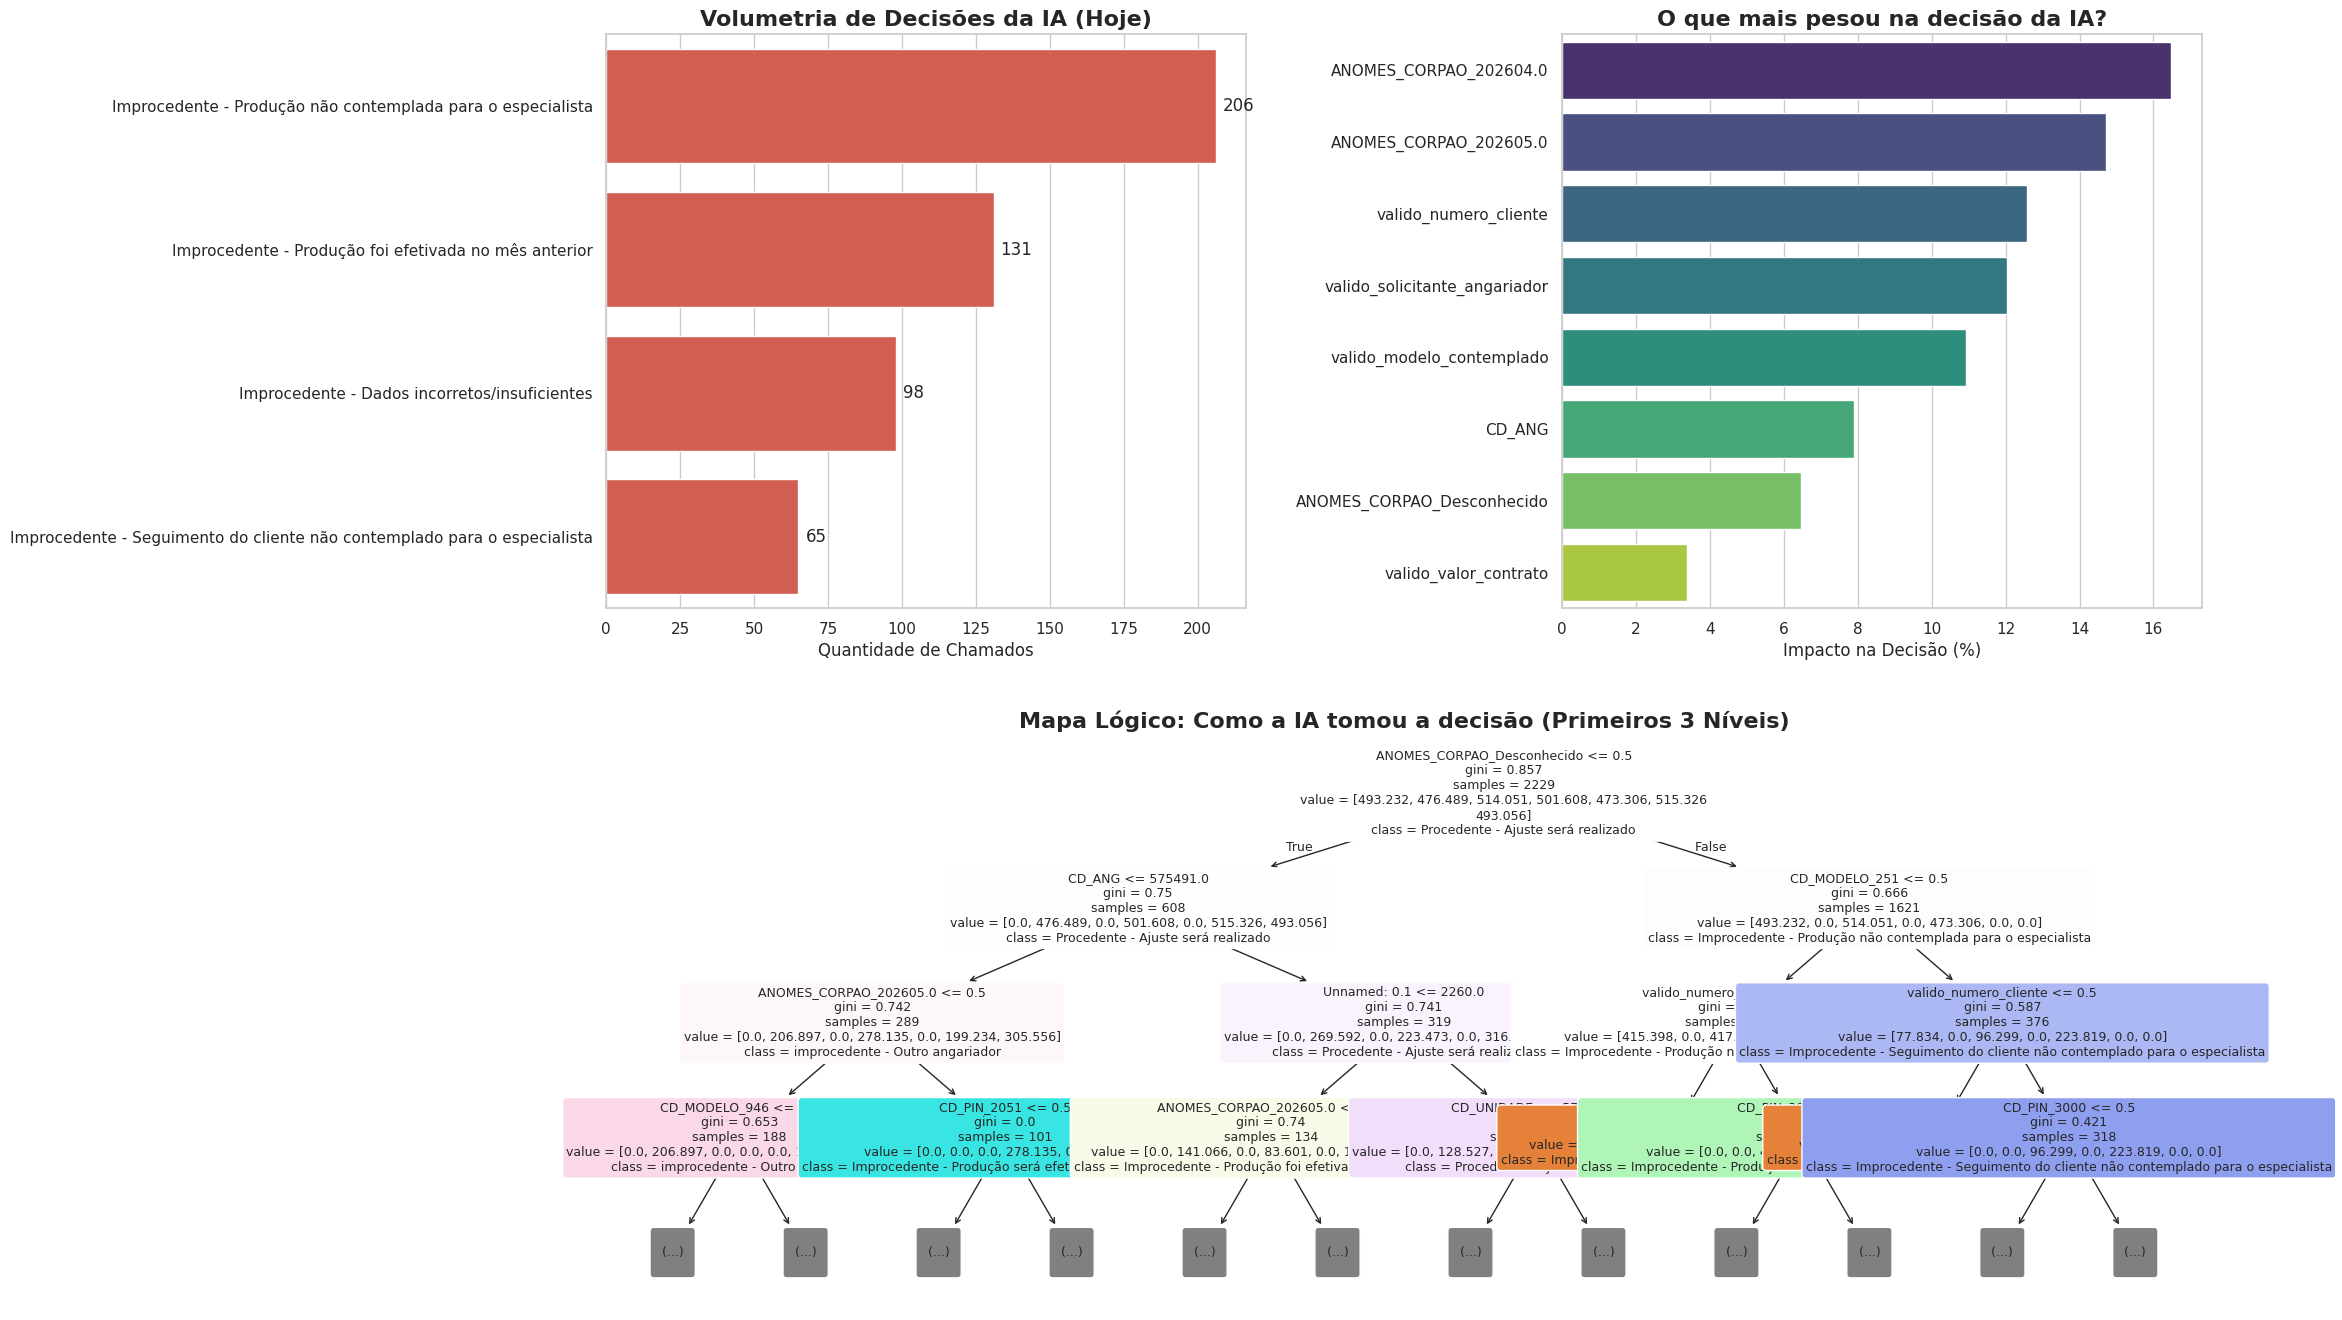

In [32]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

# Configura o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

def gerar_dashboard_ia(df_resultados, modelo_treinado, colunas_features, nomes_classes):
    """
    Gera um relatório visual completo com as predições do dia e o comportamento do modelo.
    """
    fig = plt.figure(figsize=(24, 14))
    
    # --- GRÁFICO 1: Volumetria do Dia ---
    ax1 = plt.subplot(2, 2, 1)
    contagem_status = df_resultados['status_classificacao'].value_counts()
    cores = ['#2ecc71' if 'Procedente' in status else '#e74c3c' for status in contagem_status.index]
    
    sns.barplot(y=contagem_status.index, x=contagem_status.values, palette=cores, ax=ax1)
    ax1.set_title('Volumetria de Decisões da IA (Hoje)', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Quantidade de Chamados', fontsize=12)
    ax1.set_ylabel('')
    
    for p in ax1.patches:
        ax1.annotate(f'{int(p.get_width())}', 
                     (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=12)

    # --- GRÁFICO 2: Feature Importance ---
    ax2 = plt.subplot(2, 2, 2)
    importancias = modelo_treinado.feature_importances_
    df_imp = pd.DataFrame({'Regra': colunas_features, 'Peso (%)': importancias * 100})
    df_imp = df_imp.sort_values(by='Peso (%)', ascending=False).head(8)
    
    sns.barplot(x='Peso (%)', y='Regra', data=df_imp, palette='viridis', ax=ax2)
    ax2.set_title('O que mais pesou na decisão da IA?', fontsize=16, fontweight='bold')
    ax2.set_xlabel('Impacto na Decisão (%)', fontsize=12)
    ax2.set_ylabel('')

    # --- GRÁFICO 3: A Árvore de Decisão ---
    ax3 = plt.subplot(2, 1, 2)
    arvore_exemplo = modelo_treinado.estimators_[0]
    
    plot_tree(
        arvore_exemplo,
        feature_names=colunas_features,
        class_names=nomes_classes,
        filled=True,
        rounded=True,
        max_depth=3, 
        fontsize=9,
        ax=ax3
    )
    ax3.set_title('Mapa Lógico: Como a IA tomou a decisão (Primeiros 3 Níveis)', fontsize=16, fontweight='bold')

    plt.tight_layout(pad=3.0)
    plt.show()

# =============================================================================
# BLOCO DE EXECUÇÃO INDEPENDENTE (CARREGA TUDO DO ZERO)
# =============================================================================

print("Carregando base de dados e modelos da pasta...")

# 1. Carrega os chamados que já foram classificados pela IA hoje
# (Ajuste o caminho se o nome do arquivo for diferente no seu projeto)
df_novos_chamados = pd.read_excel("./database/gold/chamados_classificados_floresta_aleatoria.xlsx")

# 2. Carrega os cérebros da IA salvos na pasta 'models'
rf_model = joblib.load("./database/models/rf_classificador_chamados.pkl")
label_encoder = joblib.load("./database/models/label_encoder_chamados.pkl")

# 3. Extrai as listas de features e classes que o modelo tem salvo dentro dele
features_do_modelo = rf_model.feature_names_in_.tolist()
classes_do_modelo = label_encoder.classes_.tolist()

print("Gerando painel analítico...")

# 4. Aciona a função geradora de gráficos
gerar_dashboard_ia(
    df_resultados=df_novos_chamados, 
    modelo_treinado=rf_model, 
    colunas_features=features_do_modelo,
    nomes_classes=classes_do_modelo
)